## 4. Weak SINDy for the EM density

Weak SINDy uses integration by parts instead of computing numerical derivatives pointwise, which reduces the amplification of noise.

For standard pointwise SINDy, suppose that the observed density at the $k$th grid point is

$$
\widehat{\rho}_k=\rho_k+\epsilon_k,
\qquad
\epsilon_k\overset{\mathrm{i.i.d.}}{\sim}\mathcal N(0,\sigma^2).
$$

Using the centred finite-difference approximation,

$$
\partial_x\widehat{\rho}_k
\approx
\frac{\widehat{\rho}_{k+1}-\widehat{\rho}_{k-1}}{2\Delta x},
$$

the corresponding differentiated noise is

$$
\frac{\epsilon_{k+1}-\epsilon_{k-1}}{2\Delta x},
$$

whose variance is

$$
\operatorname{Var}\!\left(
\frac{\epsilon_{k+1}-\epsilon_{k-1}}{2\Delta x}
\right)
=
\frac{\sigma^2}{2\Delta x^2}.
$$

Similarly, the centred finite-difference approximation of the second derivative gives

$$
\operatorname{Var}\!\left(
\frac{\epsilon_{k+1}-2\epsilon_k+\epsilon_{k-1}}{\Delta x^2}
\right)
=
\frac{6\sigma^2}{\Delta x^4}.
$$

Therefore, although reducing the grid spacing decreases the truncation error of the finite-difference approximation, it increases the variance of the differentiated noise. This helps explain why refining the spatial or temporal grid does not necessarily improve pointwise SINDy identification when the density data are noisy.

The calculation above is an illustrative independent Gaussian-noise model. The sampling error in an Euler--Maruyama histogram is not exactly independent Gaussian noise, but numerical differentiation can still amplify its high-frequency fluctuations.

Write the Ornstein--Uhlenbeck Fokker--Planck equation in conservative form as

$$
\rho_t
=
\kappa\,\partial_x(x\rho)
+
D\rho_{xx}.
$$

For each randomly sampled space--time subdomain \(\Omega_k\), Weak SINDy uses a smooth test function \(\phi_k\). The test function and the derivatives required by integration by parts vanish on the boundary of the local subdomain, so the boundary terms are zero. Therefore,

$$
-\int_{\Omega_k}\rho\,(\phi_k)_t\,dx\,dt
=
-\kappa\int_{\Omega_k}x\rho\,(\phi_k)_x\,dx\,dt
+
D\int_{\Omega_k}\rho\,(\phi_k)_{xx}\,dx\,dt.
$$

Weak SINDy therefore does not require pointwise numerical approximations of $\rho_t$, $(x\rho)_x$, or $\rho_{xx}$. Instead, the derivatives are transferred to the known smooth test function. The observed density appears only inside weighted local integrals, so its noise is not differentiated and can partially cancel under integration.

The subdomain size introduces a bias--variance trade-off. A larger subdomain averages over more observations and can suppress random fluctuations more strongly. If it is too large, however, the weak measurements may over-average local spatial and temporal variation, reduce the distinction between candidate terms, and make the PDE coefficients less identifiable.

In [1]:
# ============================================================
# Imports
# ============================================================

import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysindy as ps

from IPython.display import Math, display

import ou_em

importlib.reload(ou_em)
solve_ou_em = ou_em.solve_ou_em

In [2]:
# ============================================================
# Shared OU parameters and helper functions
# ============================================================

kappa = 1.0
D = 1.0

# Non-stationary Gaussian initial distribution
m0 = -2.0
s0 = 0.5

# Space-time domain
x_L = -5.0
x_R = 5.0
T_final = 3.0


def exact_ou_moments(t_grid, kappa, D, m0, s0):
    """Return the exact OU mean, variance and their time derivatives."""

    mean = m0 * np.exp(-kappa * t_grid)

    variance = (
        s0**2 * np.exp(-2.0 * kappa * t_grid)
        + (D / kappa) * (
            1.0 - np.exp(-2.0 * kappa * t_grid)
        )
    )

    mean_t = -kappa * mean
    variance_t = -2.0 * kappa * variance + 2.0 * D

    return mean, variance, mean_t, variance_t


def exact_ou_density(x_grid, t_grid, kappa, D, m0, s0):
    """Exact density of dX_t = -kappa X_t dt + sqrt(2D) dW_t."""

    mean, variance, _, _ = exact_ou_moments(
        t_grid,
        kappa,
        D,
        m0,
        s0,
    )

    return (
        np.exp(
            -0.5 * (x_grid - mean)**2 / variance
        )
        / np.sqrt(2.0 * np.pi * variance)
    )


def exact_ou_time_derivative(x_grid, t_grid, kappa, D, m0, s0):
    """Analytical time derivative of the exact OU density."""

    mean, variance, mean_t, variance_t = exact_ou_moments(
        t_grid,
        kappa,
        D,
        m0,
        s0,
    )

    density = exact_ou_density(
        x_grid,
        t_grid,
        kappa,
        D,
        m0,
        s0,
    )

    return density * (
        mean_t * (x_grid - mean) / variance
        + variance_t
        / (2.0 * variance**2)
        * (
            (x_grid - mean)**2 - variance
        )
    )


def relative_l2_error(approximation, reference):
    """Relative Euclidean L2 error after flattening both arrays."""

    approximation = np.asarray(approximation).ravel()
    reference = np.asarray(reference).ravel()

    reference_norm = np.linalg.norm(reference)

    if reference_norm == 0.0:
        raise ZeroDivisionError(
            "The reference array has zero L2 norm."
        )

    return (
        np.linalg.norm(approximation - reference)
        / reference_norm
    )


def print_identified_equation(feature_names, coefficients, tolerance=1e-10):
    """Display the true and identified PDEs as rendered LaTeX."""

    identified_terms = []

    for name, coefficient in zip(feature_names, coefficients):
        if abs(coefficient) > tolerance:
            latex_name = name.strip("$")
            identified_terms.append(
                (np.sign(coefficient), abs(coefficient), latex_name)
            )

    if identified_terms:
        first_sign, first_magnitude, first_name = identified_terms[0]
        first_prefix = "-" if first_sign < 0 else ""
        identified_rhs = (
            f"{first_prefix}{first_magnitude:.6f}\\,{first_name}"
        )

        for sign, magnitude, name in identified_terms[1:]:
            operator = "+" if sign > 0 else "-"
            identified_rhs += (
                f" {operator} {magnitude:.6f}\\,{name}"
            )
    else:
        identified_rhs = "0"

    true_equation = (
        rf"\rho_t = {kappa:.6f}\,\partial_x(x\rho)"
        rf" + {D:.6f}\,\rho_{{xx}}"
    )

    print("True Fokker–Planck equation:")
    display(Math(true_equation))

    print("Identified Fokker–Planck equation:")
    display(Math(rf"\rho_t = {identified_rhs}"))


def plot_error_heatmap(t_grid, x_grid, error_field, title, colorbar_label="Error"):
    """Plot a signed error field with symmetric colour limits."""

    max_abs_error = np.max(np.abs(error_field))
    max_abs_error = max(max_abs_error, np.finfo(float).eps)

    fig, ax = plt.subplots(figsize=(8, 5))

    plot = ax.pcolormesh(
        t_grid,
        x_grid,
        error_field,
        shading="auto",
        vmin=-max_abs_error,
        vmax=max_abs_error,
        cmap="coolwarm",
    )

    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$x$")
    ax.set_title(title)

    fig.colorbar(
        plot,
        ax=ax,
        label=colorbar_label,
    )

    plt.tight_layout()
    plt.show()


### 4.1 EM resolution and saved data times

In [3]:
# ============================================================
# 4.1 EM resolution and saved data times
# ============================================================

# Number of spatial intervals used by the histogram density
Nx_em = 50      # 50, 100, 200, 300

# Number of saved time intervals supplied to SINDy
Nt_data_em = 75     # 75, 150, 300, 600

# Number of internal Euler--Maruyama time steps
Nt_internal_em = 1500   # 1500, 3000, 6000, 12000

# Number of Monte Carlo sample paths
num_paths_em = 60000   # 5000, 60000, 120000

if Nt_internal_em % Nt_data_em != 0:
    raise ValueError(
        "Nt_internal_em must be divisible by Nt_data_em so every "
        "saved time lies on the internal EM time grid."
    )

save_times_em = np.linspace(
    0.0,
    T_final,
    Nt_data_em + 1,
)

print("Number of saved times:       ", save_times_em.size)
print("Internal EM time step:       ", T_final / Nt_internal_em)
print("Saved-density time spacing:  ", T_final / Nt_data_em)
print("Number of Monte Carlo paths: ", num_paths_em)


Number of saved times:        76
Internal EM time step:        0.002
Saved-density time spacing:   0.04
Number of Monte Carlo paths:  60000


### 4.2 Generate EM density snapshots

In [4]:
# ============================================================
# 4.2 Generate EM density snapshots
# ============================================================

em_solution = solve_ou_em(
    num_paths=num_paths_em,
    N_em=Nt_internal_em,
    Nx=Nx_em,
    k=kappa,
    D=D,
    x_L=x_L,
    x_R=x_R,
    m0=m0,
    s0=s0,
    T=T_final,
    save_times=save_times_em,
    seed=319,
    store_particles=False,
)


### 4.3 Convert the EM snapshots into $\rho_{\mathrm{EM}}(x,t)$

In [5]:
# ============================================================
# 4.3 Convert the EM snapshots into rho_em(x, t)
# ============================================================

x_em = np.asarray(
    em_solution["x"],
    dtype=float,
)

t_em = np.array(
    sorted(em_solution["snapshots"].keys()),
    dtype=float,
)

rho_em = np.column_stack([
    em_solution["snapshots"][saved_time]
    for saved_time in t_em
])

dx_em = float(em_solution["dx"])
dt_internal_em = float(em_solution["dt_em"])
dt_data_em = float(t_em[1] - t_em[0])

X_em, Time_em = np.meshgrid(
    x_em,
    t_em,
    indexing="ij",
)

if rho_em.shape != X_em.shape:
    raise ValueError(
        f"rho_em has shape {rho_em.shape}, "
        f"but the EM coordinate grid has shape {X_em.shape}."
    )

# Analytical reference quantities evaluated independently on the EM grid
rho_exact_em_grid = exact_ou_density(
    X_em,
    Time_em,
    kappa,
    D,
    m0,
    s0,
)

rho_t_exact_em_grid = exact_ou_time_derivative(
    X_em,
    Time_em,
    kappa,
    D,
    m0,
    s0,
)

print("rho_em shape:", rho_em.shape)
print("x spacing:   ", dx_em)
print("saved dt:    ", dt_data_em)


rho_em shape: (51, 76)
x spacing:    0.20000000000000018
saved dt:     0.04


### 4.4 Main variable names

- `rho_em`: EM-generated histogram density $\rho^{\mathrm{EM}}(x,t)$;
- `X_em`, `Time_em`: spatial and temporal coordinate arrays with the same shape as `rho_em`;
- `rho_state_weak_em`: density in the state format required by `WeakPDELibrary`, with shape $(N_x+1,N_t+1,1)$;
- `weak_input_fields_em`: the five input fields
  $$
  \rho,\quad x\rho,\quad x^2\rho,\quad x\rho^2,\quad x^2\rho^2;
  $$
- `K_weak_em`: number $K$ of randomly sampled space--time subdomains;
- `H_xt_weak_em`: requested spatial and temporal **half-widths** of each subdomain; `WeakPDELibrary` then contracts each boundary to the nearest grid point, so the realised grid-aligned widths may be slightly smaller;
- `weak_full_matrix_em`: complete weak design matrix containing all 15 zero-, first-, and second-order candidate terms;
- `weak_target_em`: weak time-derivative target,
  $$
  [\mathbf b_{\mathrm{weak}}]_k
  =
  -\int_{\Omega_k}\rho\,\partial_t\phi_k\,dx\,dt;
  $$
- variables containing `lib1`: quantities for the reduced five-term candidate library;
- variables containing `lib2`: quantities for the complete 15-term candidate library;
- `prediction_lib_em`: reconstruction
  $$
  \widehat{\mathbf b}_{\mathrm{weak}}
  =
  \mathbf G_{\mathrm{weak}}\widehat{\boldsymbol\xi};
  $$
- `residual_lib_em`: weak residual
  $$
  \mathbf r
  =
  \mathbf b_{\mathrm{weak}}
  -
  \widehat{\mathbf b}_{\mathrm{weak}}.
  $$

The predictions and residuals live in the $K$-dimensional weak-integral system. They are not pointwise approximations on the original $(x,t)$ grid.

### 4.5 Complete weak regression system

The five input fields are

$$
\rho,\qquad x\rho,\qquad x^2\rho,\qquad x\rho^2,\qquad x^2\rho^2.
$$

For each field, `WeakPDELibrary` constructs its zero-, first-, and second-order spatial weak features. Therefore, the complete design matrix has 15 columns:

$$
\mathbf b_{\mathrm{weak}}
=
\mathbf G_{\mathrm{weak}}\boldsymbol\xi,
\qquad
\mathbf b_{\mathrm{weak}}\in\mathbb R^{K\times1},
\quad
\mathbf G_{\mathrm{weak}}\in\mathbb R^{K\times15},
\quad
\boldsymbol\xi\in\mathbb R^{15\times1}.
$$

Each row corresponds to one randomly sampled subdomain $\Omega_k$. For example,

$$
[\mathbf G_{(x\rho)_x}]_k
=
-\int_{\Omega_k}x\rho\,\partial_x\phi_k\,dx\,dt,
$$

whereas

$$
[\mathbf G_{\rho_{xx}}]_k
=
\int_{\Omega_k}\rho\,\partial_{xx}\phi_k\,dx\,dt.
$$

Here $\mathbf G_{\mathrm{weak}}$ is a weak **design matrix** (or weak feature matrix), not a Gram matrix.

### 4.6 Experimental design: Lib 1 and Lib 2

To isolate the effect of candidate-library size, both regressions use:

- the same EM density data;
- the same value of $K$;
- the same subdomain half-widths $H_{xt}$;
- the same randomly sampled subdomains;
- the same weak target $\mathbf b_{\mathrm{weak}}$.

Only the candidate columns are changed.

**Lib 1** uses the reduced five-term matrix

$$
\mathbf G_{\mathrm{Lib\,1}}
=
\begin{bmatrix}
\mathbf G_{(x\rho)_x} &
\mathbf G_{(x^2\rho)_x} &
\mathbf G_{(x\rho^2)_x} &
\mathbf G_{(x^2\rho^2)_x} &
\mathbf G_{\rho_{xx}}
\end{bmatrix}.
$$

**Lib 2** uses the complete 15-column matrix $\mathbf G_{\mathrm{weak}}$.

### 4.7 Construct the common weak system

In [6]:
# ============================================================
# 4.7.1 Space-time grid and input fields
# ============================================================

# WeakPDELibrary expects the final axis of the grid to contain
# the coordinates. The resulting shape is (Nx + 1, Nt + 1, 2).
XT_em = np.stack(
    (X_em, Time_em),
    axis=-1,
)

# One dynamical state: rho(x, t)
rho_state_weak_em = rho_em[..., np.newaxis]

# Four auxiliary fields used to build conservative candidates
candidate_control_weak_em = np.stack(
    [
        X_em * rho_em,          # x rho
        X_em**2 * rho_em,       # x^2 rho
        X_em * rho_em**2,       # x rho^2
        X_em**2 * rho_em**2,    # x^2 rho^2
    ],
    axis=-1,
)

weak_input_fields_em = np.concatenate(
    [rho_state_weak_em, candidate_control_weak_em],
    axis=-1,
)

weak_input_names_em = [
    "rho",
    "xrho",
    "x2rho",
    "xrho2",
    "x2rho2",
]

print("XT_em shape:                    ", XT_em.shape)
print("rho_state_weak_em shape:        ", rho_state_weak_em.shape)
print("candidate_control_weak_em shape:", candidate_control_weak_em.shape)
print("weak_input_fields_em shape:     ", weak_input_fields_em.shape)


XT_em shape:                     (51, 76, 2)
rho_state_weak_em shape:         (51, 76, 1)
candidate_control_weak_em shape: (51, 76, 4)
weak_input_fields_em shape:      (51, 76, 5)


In [7]:
# ============================================================
# 4.7.2 Construct one common WeakPDELibrary
# ============================================================

# K is the number of randomly sampled space-time subdomains.
K_weak_em = 500    # Single baseline run; Section 4.10 sweeps several K values.

# H_xt contains the requested half-width in each coordinate direction.
# WeakPDELibrary contracts each boundary to the nearest grid point, so
# the realised grid-aligned widths can be slightly smaller than 2 * H_xt.
H_xt_weak_em = np.array([
    (x_em[-1] - x_em[0]) / 8.0,
    (t_em[-1] - t_em[0]) / 8.0,
])

# The random subdomains are selected when the library is constructed.
np.random.seed(319)

weak_library_em = ps.WeakPDELibrary(
    function_library=ps.IdentityLibrary(),
    derivative_order=2,
    spatiotemporal_grid=XT_em,
    include_bias=False,
    include_interaction=False,
    K=K_weak_em,
    H_xt=H_xt_weak_em,
    p=4,
)

print("K:                      ", K_weak_em)
print("Requested half-widths:  ", H_xt_weak_em)
print("Requested full widths:  ", 2.0 * H_xt_weak_em)


K:                       500
Requested half-widths:   [1.25  0.375]
Requested full widths:   [2.5  0.75]


In [8]:
# ============================================================
# 4.7.3 Build the complete weak design matrix and target
# ============================================================

weak_library_em.fit(weak_input_fields_em)

# Compute all zero-, first-, and second-order weak candidate columns.
weak_full_matrix_em = np.asarray(
    weak_library_em.transform(weak_input_fields_em)
)

weak_full_feature_names_em = weak_library_em.get_feature_names(
    weak_input_names_em
)

# The common weak LHS is computed on the same K subdomains:
# b_k = - integral_{Omega_k} rho * phi_t dx dt.
weak_target_em = np.asarray(
    weak_library_em.convert_u_dot_integral(
        rho_state_weak_em
    )
)

if weak_full_matrix_em.shape[0] != weak_target_em.shape[0]:
    raise ValueError(
        "The weak design matrix and weak target contain different "
        "numbers of subdomain equations."
    )

weak_display_name_em = {
    "rho": r"$\rho$",
    "xrho": r"$x \rho$",
    "x2rho": r"$x^2 \rho$",
    "xrho2": r"$x \rho^2$",
    "x2rho2": r"$x^2 \rho^2$",
    "rho_1": r"$\rho_x$",
    "xrho_1": r"$(x \rho)_x$",
    "x2rho_1": r"$(x^2 \rho)_x$",
    "xrho2_1": r"$(x \rho^2)_x$",
    "x2rho2_1": r"$(x^2 \rho^2)_x$",
    "rho_11": r"$\rho_{xx}$",
    "xrho_11": r"$(x \rho)_{xx}$",
    "x2rho_11": r"$(x^2 \rho)_{xx}$",
    "xrho2_11": r"$(x \rho^2)_{xx}$",
    "x2rho2_11": r"$(x^2 \rho^2)_{xx}$",
}

weak_true_map_em = {
    "xrho_1": kappa,
    "rho_11": D,
}

print("Full weak matrix shape:", weak_full_matrix_em.shape)
print("Weak target shape:     ", weak_target_em.shape)
print("Complete candidate terms:")
for name in weak_full_feature_names_em:
    print("  ", name)


Full weak matrix shape: (500, 15)
Weak target shape:      (500, 1)
Complete candidate terms:
   rho
   xrho
   x2rho
   xrho2
   x2rho2
   rho_1
   xrho_1
   x2rho_1
   xrho2_1
   x2rho2_1
   rho_11
   xrho_11
   x2rho_11
   xrho2_11
   x2rho2_11


### 4.8 Lib 1: reduced five-term candidate library

In [9]:
# ============================================================
# 4.8.1 Fit Lib 1
# ============================================================

feature_names_lib1_em = [
    "xrho_1",
    "x2rho_1",
    "xrho2_1",
    "x2rho2_1",
    "rho_11",
]

selected_indices_lib1_em = [
    weak_full_feature_names_em.index(name)
    for name in feature_names_lib1_em
]

regression_matrix_lib1_em = weak_full_matrix_em[
    :, selected_indices_lib1_em
]

optimizer_lib1_em = ps.STLSQ(
    threshold=0.1,
    alpha=1e-10,  # ridge-regression parameter
    max_iter=100,
    normalize_columns=True,
)

optimizer_lib1_em.fit(
    regression_matrix_lib1_em,
    weak_target_em,
)

coefficients_lib1_em = optimizer_lib1_em.coef_.reshape(-1)

print("Lib 1 regression matrix shape:", regression_matrix_lib1_em.shape)
print("Lib 1 candidate terms:")
for name in feature_names_lib1_em:
    print("  ", name)


Lib 1 regression matrix shape: (500, 5)
Lib 1 candidate terms:
   xrho_1
   x2rho_1
   xrho2_1
   x2rho2_1
   rho_11


In [10]:
# ============================================================
# 4.8.2 Lib 1 coefficient table and identified PDE
# ============================================================

readable_names_lib1_em = [
    weak_display_name_em[name]
    for name in feature_names_lib1_em
]

true_coefficients_lib1_em = np.array([
    weak_true_map_em.get(name, 0.0)
    for name in feature_names_lib1_em
])

coefficient_table_lib1_em = pd.DataFrame({
    "Candidate term": readable_names_lib1_em,
    "Identified coefficient": coefficients_lib1_em,
    "True coefficient": true_coefficients_lib1_em,
    "Absolute error": np.abs(
        coefficients_lib1_em - true_coefficients_lib1_em
    ),
})

display(
    coefficient_table_lib1_em.style.format({
        "Identified coefficient": "{:.6f}",
        "True coefficient": "{:.6f}",
        "Absolute error": "{:.3e}",
    }).set_caption(
        "Lib 1: Weak-SINDy coefficients from EM histogram density"
    )
)

print_identified_equation(
    readable_names_lib1_em,
    coefficients_lib1_em,
)


,Candidate term,Identified coefficient,True coefficient,Absolute error
0,$(x \rho)_x$,1.009440,1.000000,9.440e-03
1,$(x^2 \rho)_x$,0.000000,0.000000,0.000e+00
2,$(x \rho^2)_x$,0.000000,0.000000,0.000e+00
3,$(x^2 \rho^2)_x$,0.000000,0.000000,0.000e+00
4,$\rho_{xx}$,1.018382,1.000000,1.838e-02


True Fokker–Planck equation:


<IPython.core.display.Math object>

Identified Fokker–Planck equation:


<IPython.core.display.Math object>

In [11]:
# ============================================================
# 4.8.3 Lib 1 weak-regression residual
# ============================================================

prediction_lib1_em = (
    regression_matrix_lib1_em
    @ coefficients_lib1_em.reshape(-1, 1)
)

residual_lib1_em = weak_target_em - prediction_lib1_em

relative_residual_lib1_em = relative_l2_error(
    prediction_lib1_em,
    weak_target_em,
)

print("Weak target shape:      ", weak_target_em.shape)
print("Lib 1 prediction shape: ", prediction_lib1_em.shape)
print(
    "Lib 1 relative L2 residual:",
    f"{relative_residual_lib1_em:.6e}",
)

# This residual lives in the K-dimensional weak-integral system.


Weak target shape:       (500, 1)
Lib 1 prediction shape:  (500, 1)
Lib 1 relative L2 residual: 6.557989e-02


### 4.9 Lib 2: complete 15-term candidate library

In [12]:
# ============================================================
# 4.9.1 Fit Lib 2
# ============================================================

feature_names_lib2_em = list(
    weak_full_feature_names_em
)

regression_matrix_lib2_em = weak_full_matrix_em

optimizer_lib2_em = ps.STLSQ(
    threshold=0.1,
    alpha=1e-10,
    max_iter=100,
    normalize_columns=True,
)

optimizer_lib2_em.fit(
    regression_matrix_lib2_em,
    weak_target_em,
)

coefficients_lib2_em = optimizer_lib2_em.coef_.reshape(-1)

print("Lib 2 regression matrix shape:", regression_matrix_lib2_em.shape)
print("Lib 2 candidate terms:")
for name in feature_names_lib2_em:
    print("  ", name)


Lib 2 regression matrix shape: (500, 15)
Lib 2 candidate terms:
   rho
   xrho
   x2rho
   xrho2
   x2rho2
   rho_1
   xrho_1
   x2rho_1
   xrho2_1
   x2rho2_1
   rho_11
   xrho_11
   x2rho_11
   xrho2_11
   x2rho2_11


In [13]:
# ============================================================
# 4.9.2 Lib 2 coefficient table and identified PDE
# ============================================================

readable_names_lib2_em = [
    weak_display_name_em[name]
    for name in feature_names_lib2_em
]

true_coefficients_lib2_em = np.array([
    weak_true_map_em.get(name, 0.0)
    for name in feature_names_lib2_em
])

coefficient_table_lib2_em = pd.DataFrame({
    "Candidate term": readable_names_lib2_em,
    "Identified coefficient": coefficients_lib2_em,
    "True coefficient": true_coefficients_lib2_em,
    "Absolute error": np.abs(
        coefficients_lib2_em - true_coefficients_lib2_em
    ),
})

display(
    coefficient_table_lib2_em.style.format({
        "Identified coefficient": "{:.6f}",
        "True coefficient": "{:.6f}",
        "Absolute error": "{:.3e}",
    }).set_caption(
        "Lib 2: Weak-SINDy coefficients from EM histogram density"
    )
)

print_identified_equation(
    readable_names_lib2_em,
    coefficients_lib2_em,
)


,Candidate term,Identified coefficient,True coefficient,Absolute error
0,$\rho$,0.000000,0.000000,0.000e+00
1,$x \rho$,0.000000,0.000000,0.000e+00
2,$x^2 \rho$,0.000000,0.000000,0.000e+00
3,$x \rho^2$,0.000000,0.000000,0.000e+00
4,$x^2 \rho^2$,0.000000,0.000000,0.000e+00
5,$\rho_x$,0.000000,0.000000,0.000e+00
6,$(x \rho)_x$,1.009440,1.000000,9.440e-03
7,$(x^2 \rho)_x$,0.000000,0.000000,0.000e+00
8,$(x \rho^2)_x$,0.000000,0.000000,0.000e+00
9,$(x^2 \rho^2)_x$,0.000000,0.000000,0.000e+00


True Fokker–Planck equation:


<IPython.core.display.Math object>

Identified Fokker–Planck equation:


<IPython.core.display.Math object>

In [14]:
# ============================================================
# 4.9.3 Lib 2 weak-regression residual
# ============================================================

prediction_lib2_em = (
    regression_matrix_lib2_em
    @ coefficients_lib2_em.reshape(-1, 1)
)

residual_lib2_em = weak_target_em - prediction_lib2_em

relative_residual_lib2_em = relative_l2_error(
    prediction_lib2_em,
    weak_target_em,
)

print("Weak target shape:      ", weak_target_em.shape)
print("Lib 2 prediction shape: ", prediction_lib2_em.shape)
print(
    "Lib 2 relative L2 residual:",
    f"{relative_residual_lib2_em:.6e}",
)

# This residual lives in the K-dimensional weak-integral system.


Weak target shape:       (500, 1)
Lib 2 prediction shape:  (500, 1)
Lib 2 relative L2 residual: 6.557989e-02


### 4.10 Joint comparison over $K$ and subdomain size

The two-row comparison for only one fixed pair $(K,H_{xt})$ is not sufficient to study the effect of the weak formulation. We therefore repeat the comparison for

$$
K\in\{100,250,500,750\}
$$

and for requested subdomain full widths equal to $10\%,25\%,50\%$, and $75\%$ of the complete spatiotemporal domain lengths. If $f$ denotes this fraction, then

$$
H_{xt}=\frac12\left(fL_x,\,fL_t\right),
$$

because **WeakPDELibrary** expects half-widths, not full widths.

For every pair $(K,H_{xt})$, one common 15-column weak system is constructed first. Lib 1 selects its five columns from that system, while Lib 2 uses all 15 columns. Thus, within each parameter pair, both libraries use exactly the same weak target and the same sampled subdomains.

To test sensitivity to the random placement of the weak subdomains, the complete sweep is repeated with weak-subdomain seeds $319$, $802$, and $2002$. The EM density itself is **not regenerated**: `solve_ou_em` continues to use `seed=319`, so all three sweeps use the same histogram data and differ only in the sampled weak subdomains.

The relative coefficient error is

$$
E_{\xi}
=
\frac{\lVert\widehat{\boldsymbol\xi}-\boldsymbol\xi^\star\rVert_2}
{\lVert\boldsymbol\xi^\star\rVert_2}.
$$

It is reported together with the relative weak residual. The coefficient error is essential because a larger library can achieve a small residual by retaining incorrect terms.

In [15]:
# ============================================================
# 4.10.1 One reusable comparison for a single (K, H_xt)
# ============================================================

def run_weak_library_comparison(K, H_xt, random_seed=319):
    """Fit Lib 1 and Lib 2 on one common weak system for one seed."""

    if not isinstance(K, (int, np.integer)):
        raise TypeError("K must be one integer for each WeakPDELibrary call.")

    if K <= 0:
        raise ValueError("K must be positive.")

    H_xt = np.asarray(H_xt, dtype=float)

    if H_xt.shape != (XT_em.shape[-1],):
        raise ValueError(
            "H_xt must contain one half-width for x and one for t."
        )

    # This seed changes only the random weak-subdomain locations.
    # It does not regenerate the fixed EM histogram density.
    random_seed = int(random_seed)
    np.random.seed(random_seed)

    weak_library = ps.WeakPDELibrary(
        function_library=ps.IdentityLibrary(),
        derivative_order=2,
        spatiotemporal_grid=XT_em,
        include_bias=False,
        include_interaction=False,
        K=int(K),
        H_xt=H_xt,
        p=4,
    )

    weak_library.fit(weak_input_fields_em)

    full_matrix = np.asarray(
        weak_library.transform(weak_input_fields_em)
    )

    full_feature_names = weak_library.get_feature_names(
        weak_input_names_em
    )

    weak_target = np.asarray(
        weak_library.convert_u_dot_integral(
            rho_state_weak_em
        )
    )

    library_definitions = {
        "Lib 1": list(feature_names_lib1_em),
        "Lib 2": list(full_feature_names),
    }

    result_rows = []

    for library_name, feature_names in library_definitions.items():
        selected_indices = [
            full_feature_names.index(name)
            for name in feature_names
        ]

        regression_matrix = full_matrix[:, selected_indices]

        optimizer = ps.STLSQ(
            threshold=0.1,
            alpha=1e-10,
            max_iter=100,
            normalize_columns=True,
        )

        # Some deliberately poor settings eliminate every term. The
        # result table records that failure, so the repeated warning is
        # suppressed here to keep the three-seed sweep output readable.
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="Sparsity parameter is too big.*",
            )
            optimizer.fit(regression_matrix, weak_target)
        coefficients = optimizer.coef_.reshape(-1)

        true_coefficients = np.array([
            weak_true_map_em.get(name, 0.0)
            for name in feature_names
        ])

        prediction = (
            regression_matrix
            @ coefficients.reshape(-1, 1)
        )

        nonzero_mask = np.abs(coefficients) > 1e-10
        identified_support = {
            name
            for name, is_nonzero in zip(feature_names, nonzero_mask)
            if is_nonzero
        }
        true_support = set(weak_true_map_em)

        coefficient_lookup = dict(zip(feature_names, coefficients))

        result_rows.append({
            "Weak subdomain seed": random_seed,
            "Library": library_name,
            "K": int(K),
            "Number of candidate terms": len(feature_names),
            "Number of nonzero coefficients": int(np.sum(nonzero_mask)),
            "Number of spurious terms": len(
                identified_support - true_support
            ),
            "Number of missed true terms": len(
                true_support - identified_support
            ),
            "Correct support": identified_support == true_support,
            "Identified kappa": coefficient_lookup.get("xrho_1", 0.0),
            "Identified D": coefficient_lookup.get("rho_11", 0.0),
            "Relative coefficient error": relative_l2_error(
                coefficients,
                true_coefficients,
            ),
            "Relative weak residual": relative_l2_error(
                prediction,
                weak_target,
            ),
        })

    return result_rows


In [16]:
# ============================================================
# 4.10.2 Sweep K and the requested subdomain size
# ============================================================

# K is still an integer in every WeakPDELibrary call. This array
# merely stores the four integer values used by the K loop.
K_values_weak_em = np.array([100, 250, 500, 750], dtype=int)

# These seeds change only the random placement of weak subdomains.
# The EM density above remains fixed with solve_ou_em(..., seed=319).
weak_subdomain_seeds_em = np.array([319, 802, 2002], dtype=int)

# Each number is the requested full support width as a fraction
# of the corresponding full x- or t-domain length.
subdomain_full_width_fractions_em = np.array([
    0.10,
    0.25,
    0.50,
    0.75,
])

domain_lengths_xt_em = np.array([
    x_em[-1] - x_em[0],
    t_em[-1] - t_em[0],
])

comparison_rows_em = []

for weak_seed in weak_subdomain_seeds_em:
    for K_value in K_values_weak_em:
        for full_width_fraction in subdomain_full_width_fractions_em:
            # WeakPDELibrary requires half-widths, hence the factor 0.5.
            H_xt_value = (
                0.5
                * full_width_fraction
                * domain_lengths_xt_em
            )

            setting_rows = run_weak_library_comparison(
                K=int(K_value),
                H_xt=H_xt_value,
                random_seed=int(weak_seed),
            )

            for row in setting_rows:
                row.update({
                    "Requested full-width fraction": full_width_fraction,
                    "Requested spatial full width": 2.0 * H_xt_value[0],
                    "Requested temporal full width": 2.0 * H_xt_value[1],
                })

            comparison_rows_em.extend(setting_rows)

comparison_results_em = pd.DataFrame(comparison_rows_em)

comparison_table_em = comparison_results_em[
    [
        "Weak subdomain seed",
        "Library",
        "K",
        "Requested full-width fraction",
        "Requested spatial full width",
        "Requested temporal full width",
        "Number of candidate terms",
        "Number of nonzero coefficients",
        "Number of spurious terms",
        "Number of missed true terms",
        "Correct support",
        "Identified kappa",
        "Identified D",
        "Relative coefficient error",
        "Relative weak residual",
    ]
].sort_values(
    [
        "Weak subdomain seed",
        "K",
        "Requested full-width fraction",
        "Library",
    ],
    ignore_index=True,
)

print("Completed parameter settings:", len(comparison_rows_em) // 2)


Completed parameter settings: 48


,Weak subdomain seed,Library,K,Requested full-width fraction,Requested spatial full width,Requested temporal full width,Number of candidate terms,Number of nonzero coefficients,Number of spurious terms,Number of missed true terms,Correct support,Identified kappa,Identified D,Relative coefficient error,Relative weak residual
0,319,Lib 1,100,10%,1.000,0.300,5,0,0,2,False,0.000000,0.000000,1.000000e+00,1.000000e+00
1,319,Lib 2,100,10%,1.000,0.300,15,0,0,2,False,0.000000,0.000000,1.000000e+00,1.000000e+00
2,319,Lib 1,100,25%,2.500,0.750,5,2,0,0,True,1.004552,1.010228,7.916041e-03,3.740466e-02
3,319,Lib 2,100,25%,2.500,0.750,15,2,0,0,True,1.004552,1.010228,7.916041e-03,3.740466e-02
4,319,Lib 1,100,50%,5.000,1.500,5,2,0,0,True,1.005822,1.006219,6.024126e-03,1.669503e-02
5,319,Lib 2,100,50%,5.000,1.500,15,2,0,0,True,1.005822,1.006219,6.024126e-03,1.669503e-02
6,319,Lib 1,100,75%,7.500,2.250,5,2,0,0,True,0.997884,0.996270,3.032172e-03,5.558113e-03
7,319,Lib 2,100,75%,7.500,2.250,15,13,12,1,False,0.000000,0.628837,6.172884e+00,5.937772e-04
8,319,Lib 1,250,10%,1.000,0.300,5,0,0,2,False,0.000000,0.000000,1.000000e+00,1.000000e+00
9,319,Lib 2,250,10%,1.000,0.300,15,0,0,2,False,0.000000,0.000000,1.000000e+00,1.000000e+00


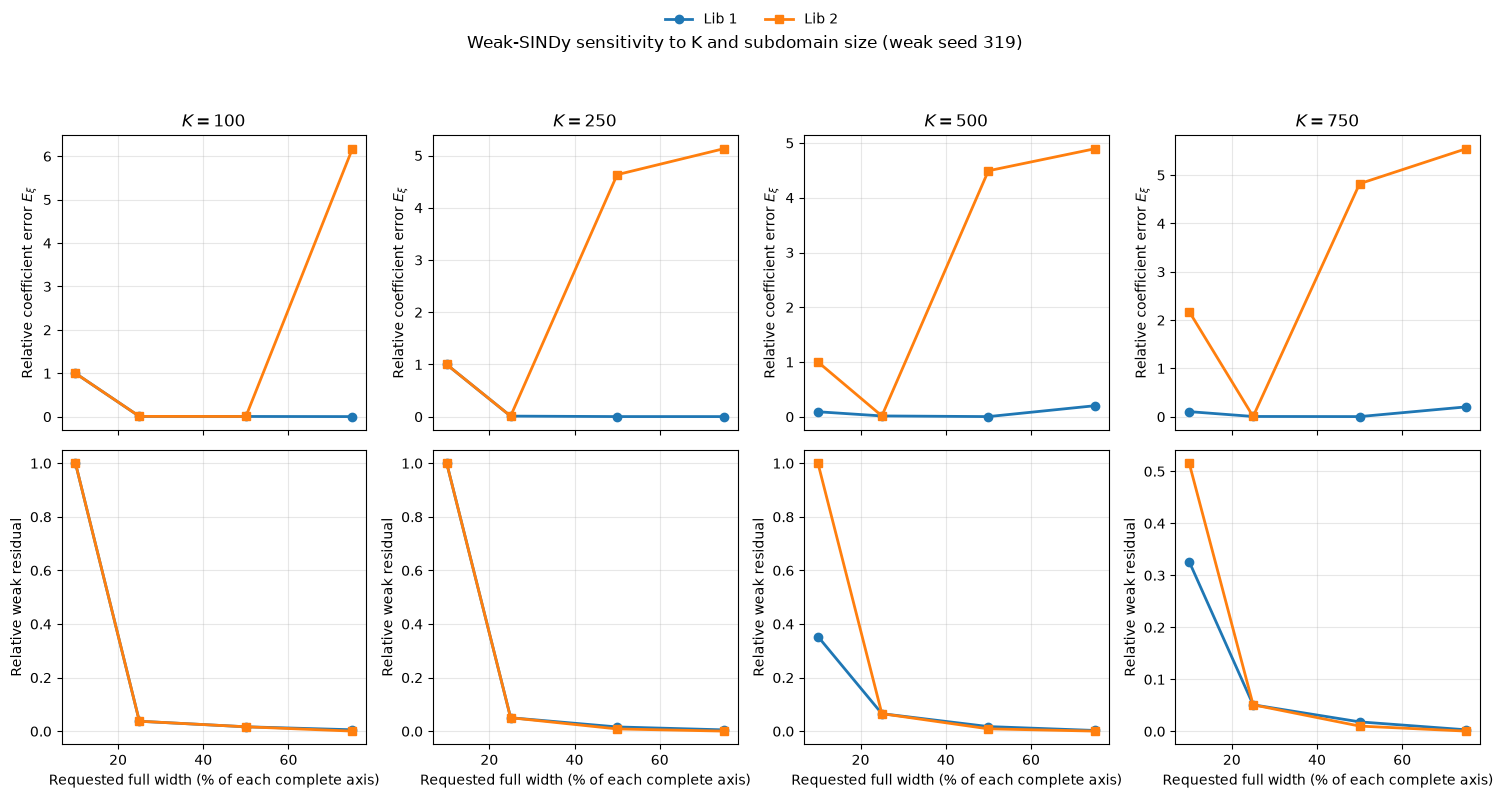

,Weak subdomain seed,Library,K,Requested full-width fraction,Requested spatial full width,Requested temporal full width,Number of candidate terms,Number of nonzero coefficients,Number of spurious terms,Number of missed true terms,Correct support,Identified kappa,Identified D,Relative coefficient error,Relative weak residual
32,802,Lib 1,100,10%,1.000,0.300,5,0,0,2,False,0.000000,0.000000,1.000000e+00,1.000000e+00
33,802,Lib 2,100,10%,1.000,0.300,15,0,0,2,False,0.000000,0.000000,1.000000e+00,1.000000e+00
34,802,Lib 1,100,25%,2.500,0.750,5,2,0,0,True,1.006755,1.022415,1.655377e-02,5.950151e-02
35,802,Lib 2,100,25%,2.500,0.750,15,2,0,0,True,1.006755,1.022415,1.655377e-02,5.950151e-02
36,802,Lib 1,100,50%,5.000,1.500,5,2,0,0,True,1.002295,1.002934,2.633926e-03,1.941502e-02
37,802,Lib 2,100,50%,5.000,1.500,15,13,12,1,False,0.000000,0.703379,5.398937e+00,1.016421e-02
38,802,Lib 1,100,75%,7.500,2.250,5,2,0,0,True,0.997137,0.995179,3.964487e-03,5.132254e-03
39,802,Lib 2,100,75%,7.500,2.250,15,14,12,0,False,0.117636,0.657561,5.269673e+00,5.530960e-04
40,802,Lib 1,250,10%,1.000,0.300,5,0,0,2,False,0.000000,0.000000,1.000000e+00,1.000000e+00
41,802,Lib 2,250,10%,1.000,0.300,15,0,0,2,False,0.000000,0.000000,1.000000e+00,1.000000e+00


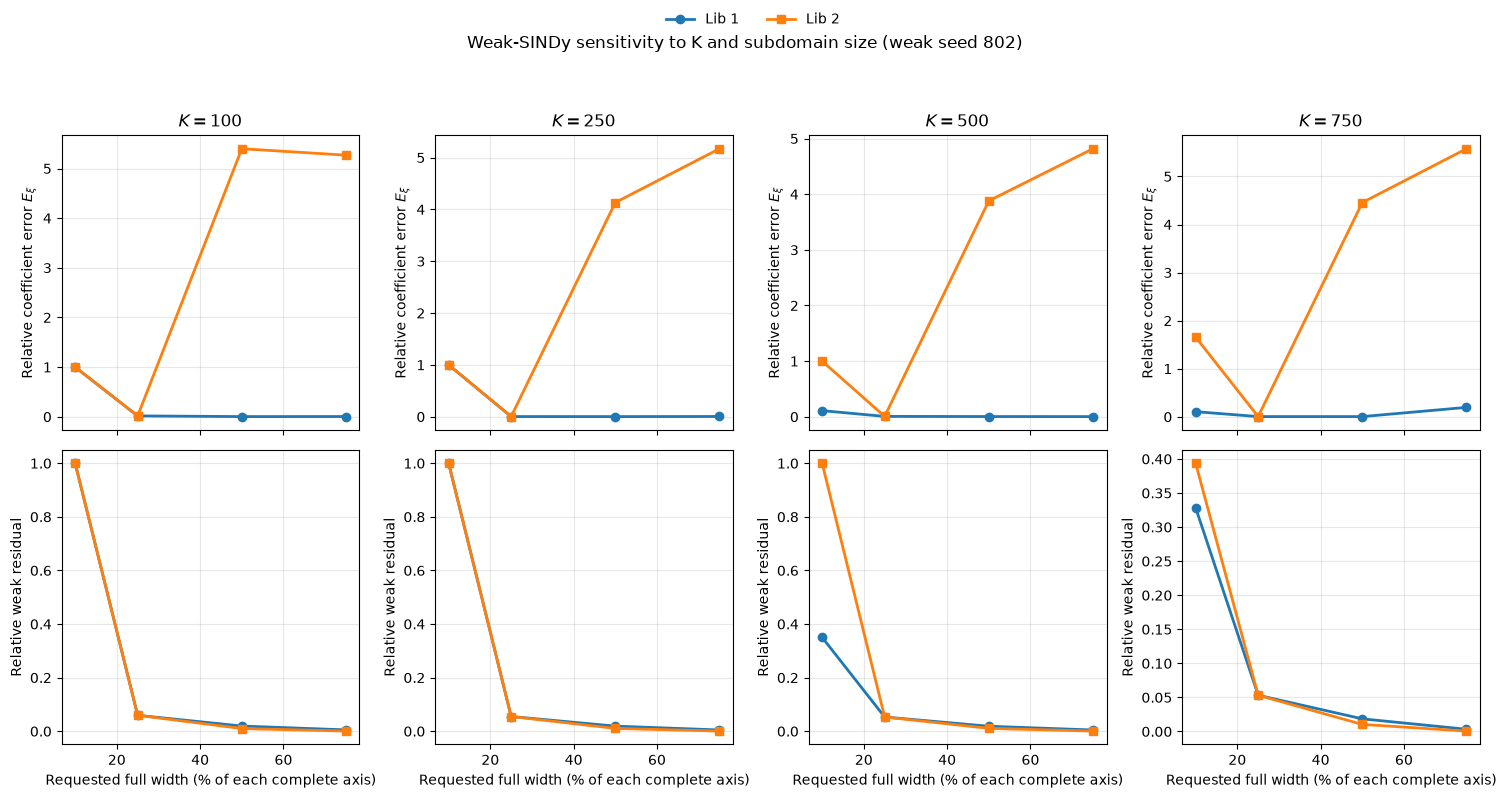

,Weak subdomain seed,Library,K,Requested full-width fraction,Requested spatial full width,Requested temporal full width,Number of candidate terms,Number of nonzero coefficients,Number of spurious terms,Number of missed true terms,Correct support,Identified kappa,Identified D,Relative coefficient error,Relative weak residual
64,2002,Lib 1,100,10%,1.000,0.300,5,0,0,2,False,0.000000,0.000000,1.000000e+00,1.000000e+00
65,2002,Lib 2,100,10%,1.000,0.300,15,0,0,2,False,0.000000,0.000000,1.000000e+00,1.000000e+00
66,2002,Lib 1,100,25%,2.500,0.750,5,2,0,0,True,1.003855,1.008192,6.402182e-03,4.933206e-02
67,2002,Lib 2,100,25%,2.500,0.750,15,2,0,0,True,1.003855,1.008192,6.402182e-03,4.933206e-02
68,2002,Lib 1,100,50%,5.000,1.500,5,2,0,0,True,1.004167,1.003419,3.811387e-03,1.692750e-02
69,2002,Lib 2,100,50%,5.000,1.500,15,14,12,0,False,0.381304,0.798539,4.061751e+00,9.377147e-03
70,2002,Lib 1,100,75%,7.500,2.250,5,2,0,0,True,0.997613,0.995588,3.547101e-03,4.944171e-03
71,2002,Lib 2,100,75%,7.500,2.250,15,14,12,0,False,0.146487,0.671925,5.233724e+00,5.377267e-04
72,2002,Lib 1,250,10%,1.000,0.300,5,0,0,2,False,0.000000,0.000000,1.000000e+00,1.000000e+00
73,2002,Lib 2,250,10%,1.000,0.300,15,0,0,2,False,0.000000,0.000000,1.000000e+00,1.000000e+00


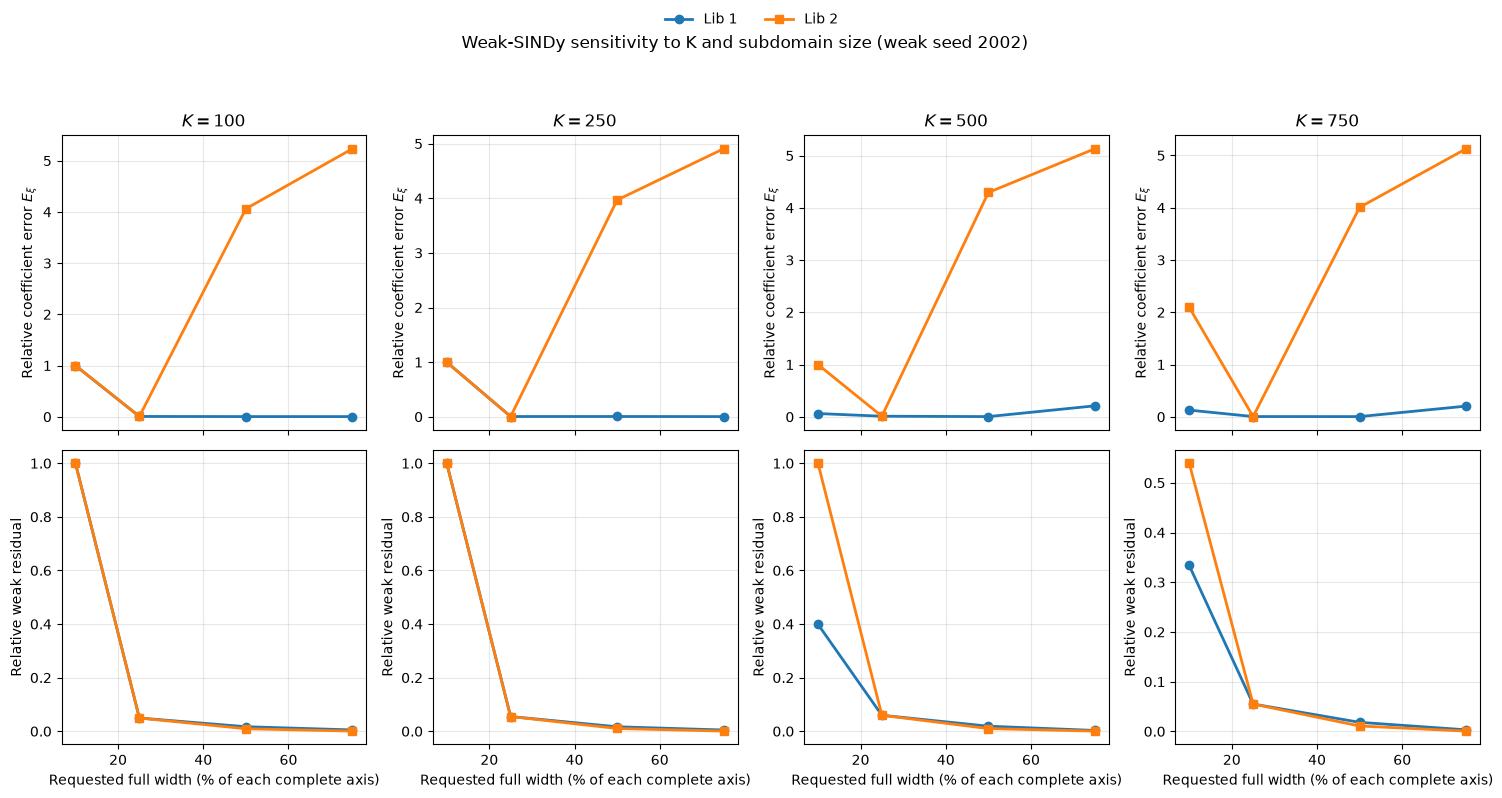

,Library,Requested full-width fraction,Correct-support count,Total settings,Median coefficient error,Maximum coefficient error,Median weak residual,Correct-support rate
0,Lib 1,10%,6,12,5.639741e-01,1.000000e+00,6.996002e-01,50%
1,Lib 1,25%,12,12,6.570369e-03,1.655377e-02,5.404203e-02,100%
2,Lib 1,50%,12,12,3.813071e-03,6.024126e-03,1.824963e-02,100%
3,Lib 1,75%,7,12,3.755794e-03,2.101513e-01,4.662598e-03,58%
4,Lib 2,10%,0,12,1.000000e+00,2.176606e+00,1.000000e+00,0%
5,Lib 2,25%,12,12,6.570369e-03,1.655377e-02,5.404203e-02,100%
6,Lib 2,50%,1,12,4.213837e+00,5.398937e+00,1.023307e-02,8%
7,Lib 2,75%,0,12,5.151588e+00,6.172884e+00,5.377353e-04,0%


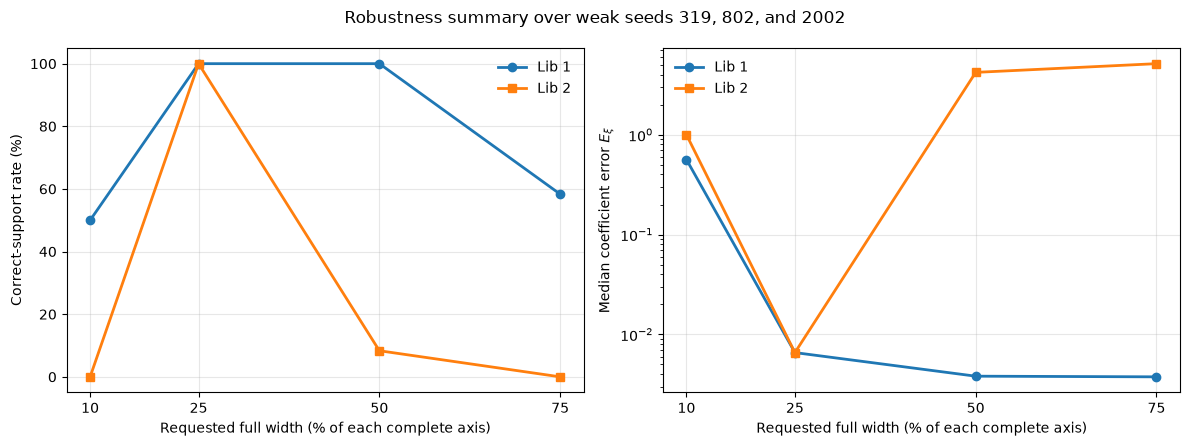

In [17]:
# ============================================================
# 4.10.3 Display and plot the joint comparison
# ============================================================

table_format_em = {
    "Requested full-width fraction": "{:.0%}",
    "Requested spatial full width": "{:.3f}",
    "Requested temporal full width": "{:.3f}",
    "Identified kappa": "{:.6f}",
    "Identified D": "{:.6f}",
    "Relative coefficient error": "{:.6e}",
    "Relative weak residual": "{:.6e}",
}

metric_rows = [
    ("Relative coefficient error", r"Relative coefficient error $E_\xi$"),
    ("Relative weak residual", "Relative weak residual"),
]

library_styles = {
    "Lib 1": {"marker": "o", "linewidth": 2.0},
    "Lib 2": {"marker": "s", "linewidth": 2.0},
}

for weak_seed in weak_subdomain_seeds_em:
    seed_table_em = comparison_table_em[
        comparison_table_em["Weak subdomain seed"] == int(weak_seed)
    ]

    display(
        seed_table_em.style.format(table_format_em).set_caption(
            f"Lib 1 and Lib 2: weak-subdomain seed {int(weak_seed)}"
        )
    )

    seed_results_em = comparison_results_em[
        comparison_results_em["Weak subdomain seed"] == int(weak_seed)
    ]

    fig, axes = plt.subplots(
        nrows=2,
        ncols=len(K_values_weak_em),
        figsize=(15, 8),
        sharex="col",
        squeeze=False,
    )

    for column, K_value in enumerate(K_values_weak_em):
        K_rows = seed_results_em[
            seed_results_em["K"] == int(K_value)
        ]

        for row_index, (metric, ylabel) in enumerate(metric_rows):
            ax = axes[row_index, column]

            for library_name, style in library_styles.items():
                library_rows = K_rows[
                    K_rows["Library"] == library_name
                ].sort_values("Requested full-width fraction")

                ax.plot(
                    100.0 * library_rows["Requested full-width fraction"],
                    library_rows[metric],
                    label=library_name,
                    **style,
                )

            ax.grid(alpha=0.3)
            ax.set_ylabel(ylabel)

            if row_index == 0:
                ax.set_title(rf"$K={int(K_value)}$")

            if row_index == 1:
                ax.set_xlabel(
                    "Requested full width (% of each complete axis)"
                )

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        frameon=False,
    )
    fig.suptitle(
        (
            "Weak-SINDy sensitivity to K and subdomain size "
            f"(weak seed {int(weak_seed)})"
        ),
        y=0.96,
    )
    fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.92))
    plt.show()

# Pool the 3 seeds and 4 K values to test which width is robust.
seed_summary_em = (
    comparison_results_em.groupby(
        ["Library", "Requested full-width fraction"],
        as_index=False,
    )
    .agg(
        support_successes=("Correct support", "sum"),
        total_settings=("Correct support", "size"),
        median_coefficient_error=("Relative coefficient error", "median"),
        maximum_coefficient_error=("Relative coefficient error", "max"),
        median_weak_residual=("Relative weak residual", "median"),
    )
)
seed_summary_em["Correct-support rate"] = (
    seed_summary_em["support_successes"]
    / seed_summary_em["total_settings"]
)

seed_summary_display_em = seed_summary_em.rename(columns={
    "support_successes": "Correct-support count",
    "total_settings": "Total settings",
    "median_coefficient_error": "Median coefficient error",
    "maximum_coefficient_error": "Maximum coefficient error",
    "median_weak_residual": "Median weak residual",
})

display(
    seed_summary_display_em.style.format({
        "Requested full-width fraction": "{:.0%}",
        "Median coefficient error": "{:.6e}",
        "Maximum coefficient error": "{:.6e}",
        "Median weak residual": "{:.6e}",
        "Correct-support rate": "{:.0%}",
    }).set_caption(
        "Summary over 3 weak seeds and 4 K values (12 settings per row)"
    )
)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4.5))

for library_name, style in library_styles.items():
    library_summary = seed_summary_em[
        seed_summary_em["Library"] == library_name
    ].sort_values("Requested full-width fraction")

    width_percent = (
        100.0 * library_summary["Requested full-width fraction"]
    )

    axes[0].plot(
        width_percent,
        100.0 * library_summary["Correct-support rate"],
        label=library_name,
        **style,
    )
    axes[1].plot(
        width_percent,
        library_summary["median_coefficient_error"],
        label=library_name,
        **style,
    )

axes[0].set_ylabel("Correct-support rate (%)")
axes[0].set_ylim(-5.0, 105.0)
axes[1].set_ylabel(r"Median coefficient error $E_\xi$")
axes[1].set_yscale("log")

for ax in axes:
    ax.set_xlabel("Requested full width (% of each complete axis)")
    ax.set_xticks(100.0 * subdomain_full_width_fractions_em)
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

fig.suptitle("Robustness summary over weak seeds 319, 802, and 2002")
fig.tight_layout()
plt.show()


### 4.11 Conclusion

This experiment shows that Weak-SINDy identification depends jointly on the subdomain size, the number $K$ of weak equations, the random placement of the weak subdomains, and the size of the candidate library. The EM histogram data are held fixed, while the weak-subdomain seeds $319$, $802$, and $2002$ change only the sampled integration regions. The subdomain size controls how much averaging occurs inside each weak measurement, whereas $K$ controls how many randomly sampled weak measurements are supplied to the regression. Therefore, increasing $K$ does not have the same effect as enlarging the subdomains.

For the smallest subdomains, with full width equal to $10\%$ of each complete axis, the local integrals do not average the EM histogram fluctuations sufficiently. Across the three seeds and four values of $K$, Lib 1 recovers the correct support in only $6/12$ settings, namely at $K=500$ and $K=750$ for each seed, with coefficient errors between approximately $0.0624$ and $0.1279$. Lib 2 recovers the correct support in $0/12$ settings. Hence, a larger $K$ can provide more constraints, but it cannot fully compensate for weak measurements that are individually too noisy.

The most robust common choice in the present sweep is a $25\%$ full-width subdomain. For each library, all $12/12$ combinations of three weak seeds and four values of $K$ recover exactly $(x\rho)_x$ and $\rho_{xx}$. The relative coefficient error ranges from approximately $0.0023$ to $0.0166$. Lib 1 also recovers the correct support in all $12/12$ settings at $50\%$, with smaller coefficient errors between approximately $0.0015$ and $0.0060$. However, at the same $50\%$ width, Lib 2 is correct in only $1/12$ settings (seed $319$, $K=100$) and otherwise retains spurious terms. Thus, $50\%$ can be preferable for the reduced library, but it is not robust to enlarging the candidate library.

Very large subdomains illustrate the other side of the trade-off. At $75\%$, Lib 1 is correct in only $7/12$ settings and Lib 2 is correct in $0/12$. For Lib 2, the median coefficient error is approximately $5.15$ even though the median weak residual is only about $5.4\times10^{-4}$. This is consistent with over-averaging: large supports suppress noise strongly, but they can also make different candidate columns less distinguishable. The small residual then measures a good fit to the weak equations, not correct PDE identification. The variation in Lib 1 at $75\%$ also shows that borderline settings can depend on the particular random subdomains.

The effect of $K$ is therefore real but non-monotone in this experiment. A larger $K$ supplies more weak equations and may reduce sampling variability, but many large, overlapping subdomains can add redundant rather than independent information. Changing $K$ also changes the empirical weak design matrix and can alter the path followed by thresholded regression. Consequently, the largest tested $K$ is not automatically the best choice. The three-seed experiment confirms the previous qualitative conclusion: for the present fixed EM data, resolution, and STLSQ threshold, $25\%$ is the safest choice across both libraries, while $50\%$ is preferable only if the reduced Lib 1 is used. Three seeds provide substantially stronger evidence than one, although the numerical ranges should not be treated as universal because the EM realisation itself remains fixed.